# MATH 5010 Computer Lab — Section 4
## Expectations, Moments, and Moment Generating Functions

**Full-solution version**

This lab supports Section 4 of MATH 5010. It focuses on computational understanding of:

1. Expected value as long-run average
2. Expectation of functions $E[g(X)]$
3. Linearity of expectation
4. Variance and standard deviation
5. Raw moments, centered moments, skewness, and kurtosis
6. Moment generating functions (MGFs)
7. Using MGFs to identify distributions and sums of independent variables

The goal is not only to compute answers, but to connect Python calculations with the formulas from probability theory.

## 0. Setup

Run the following cell first. We use `numpy`, `pandas`, `matplotlib`, `scipy`, and `sympy`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats, integrate
import sympy as sp

rng = np.random.default_rng(5010)
np.set_printoptions(precision=4, suppress=True)

## 1. Expected Value for a Discrete Random Variable

For a discrete random variable $X$ with possible values $x_k$ and probabilities $p_X(x_k)$,

$$
E[X] = \sum_k x_k p_X(x_k).
$$

### Example 1.1: Bernoulli random variable

Let $X \sim \mathrm{Bernoulli}(p)$. Then $X=1$ with probability $p$ and $X=0$ with probability $1-p$.

Compute $E[X]$ directly.

In [2]:
p = 0.3
values = np.array([0, 1])
probs = np.array([1-p, p])
EX = np.sum(values * probs)
EX

np.float64(0.3)

### Solution

$$
E[X] = 0(1-p) + 1p = p.
$$

For $p=0.3$, the expected value is $0.3$.

### Practice 1.1

Let $X$ be the outcome of rolling a fair six-sided die. Compute $E[X]$.

In [3]:
# Solution
values = np.arange(1, 7)
probs = np.repeat(1/6, 6)
EX_die = np.sum(values * probs)
EX_die

np.float64(3.5)

### Solution

$$
E[X] = \frac{1+2+3+4+5+6}{6} = 3.5.
$$

## 2. Expected Value as Long-Run Average

The expected value is the long-run average value of repeated measurements. If $X_1,\ldots,X_n$ are iid copies of $X$, then

$$
\bar X_n = \frac{1}{n}\sum_{i=1}^n X_i
$$

should approach $E[X]$ as $n$ becomes large.

### Example 2.1: Long-run average of die rolls

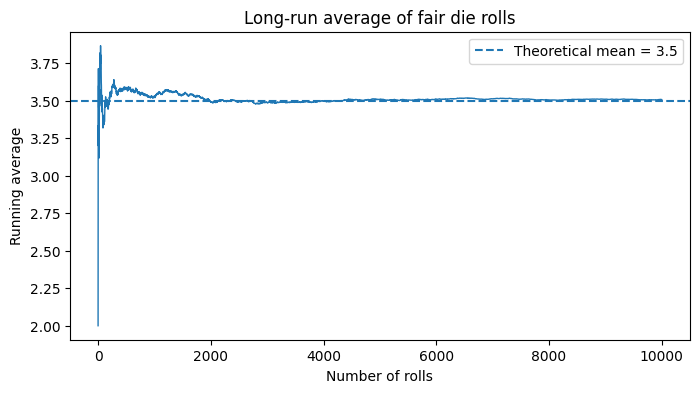

np.float64(3.5075)

In [4]:
n = 10_000
rolls = rng.integers(1, 7, size=n)
running_mean = np.cumsum(rolls) / np.arange(1, n+1)

plt.figure(figsize=(8, 4))
plt.plot(running_mean, linewidth=1)
plt.axhline(3.5, linestyle='--', label='Theoretical mean = 3.5')
plt.xlabel('Number of rolls')
plt.ylabel('Running average')
plt.title('Long-run average of fair die rolls')
plt.legend()
plt.show()

running_mean[-1]

### Solution

The sample average fluctuates at first but stabilizes near

$$
E[X] = 3.5.
$$

This illustrates the operational meaning of expectation as a long-run average.

### Practice 2.1

Simulate $X \sim \mathrm{Bernoulli}(0.7)$ for $n=20{,}000$ trials and show that the running average approaches $0.7$.

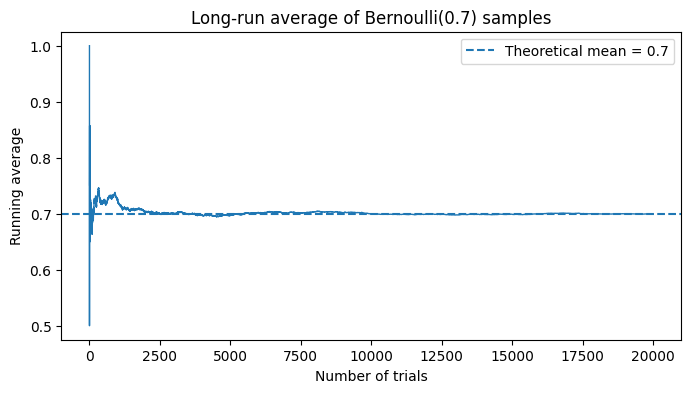

np.float64(0.69945)

In [5]:
# Solution
n = 20_000
p = 0.7
samples = rng.binomial(1, p, size=n)
running_mean = np.cumsum(samples) / np.arange(1, n+1)

plt.figure(figsize=(8, 4))
plt.plot(running_mean, linewidth=1)
plt.axhline(p, linestyle='--', label='Theoretical mean = 0.7')
plt.xlabel('Number of trials')
plt.ylabel('Running average')
plt.title('Long-run average of Bernoulli(0.7) samples')
plt.legend()
plt.show()

running_mean[-1]

### Solution

For $X\sim \mathrm{Bernoulli}(0.7)$,

$$
E[X]=0(0.3)+1(0.7)=0.7.
$$

The simulated running average should approach $0.7$.

## 3. Expectation of a Function $E[g(X)]$

For a discrete random variable,

$$
E[g(X)] = \sum_x g(x)p_X(x).
$$

For a continuous random variable,

$$
E[g(X)] = \int_{-\infty}^{\infty} g(x) f_X(x)\,dx.
$$

A common mistake is to think $E[g(X)] = g(E[X])$. This is usually false.

### Example 3.1: $E[X^2]$ for a die

In [6]:
values = np.arange(1, 7)
probs = np.repeat(1/6, 6)
EX = np.sum(values * probs)
EX2 = np.sum(values**2 * probs)
print('E[X]  =', EX)
print('E[X^2]=', EX2)
print('(E[X])^2 =', EX**2)

E[X]  = 3.5
E[X^2]= 15.166666666666666
(E[X])^2 = 12.25


### Solution

For a fair die,

$$
E[X^2] = \frac{1^2+2^2+3^2+4^2+5^2+6^2}{6} = \frac{91}{6} \approx 15.1667.
$$

But

$$
(E[X])^2 = 3.5^2 = 12.25.
$$

So

$$
E[X^2] \ne (E[X])^2.
$$

### Practice 3.1

Let $X\sim \mathrm{Uniform}(0,1)$. Compute $E[X^2]$ using numerical integration and compare with $(E[X])^2$.

In [7]:
# Solution
EX, _ = integrate.quad(lambda x: x * 1, 0, 1)
EX2, _ = integrate.quad(lambda x: x**2 * 1, 0, 1)
print('E[X] =', EX)
print('E[X^2] =', EX2)
print('(E[X])^2 =', EX**2)

E[X] = 0.5
E[X^2] = 0.33333333333333337
(E[X])^2 = 0.25


### Solution

For $X\sim \mathrm{Uniform}(0,1)$,

$$
E[X] = \int_0^1 x\,dx = \frac12,
$$

and

$$
E[X^2] = \int_0^1 x^2\,dx = \frac13.
$$

Therefore

$$
E[X^2] = \frac13 \ne \frac14 = (E[X])^2.
$$

## 4. Linearity of Expectation

For any random variables $X,Y$ and constants $a,b$,

$$
E[aX+bY] = aE[X]+bE[Y].
$$

This is true whether or not $X$ and $Y$ are independent.

### Example 4.1: Dependent random variables

Let $X\sim \mathrm{Uniform}(0,1)$ and let $Y=X^2$. Then $X$ and $Y$ are dependent. Verify numerically that

$$
E[3X-2Y] = 3E[X]-2E[Y].
$$

In [8]:
n = 1_000_000
X = rng.uniform(0, 1, size=n)
Y = X**2
lhs = np.mean(3*X - 2*Y)
rhs = 3*np.mean(X) - 2*np.mean(Y)
print('Left side  E[3X - 2Y]     =', lhs)
print('Right side 3E[X] - 2E[Y]  =', rhs)

Left side  E[3X - 2Y]     = 0.8337593294267026
Right side 3E[X] - 2E[Y]  = 0.8337593294267026


### Solution

Even though $Y=X^2$ is completely determined by $X$, linearity still holds:

$$
E[3X-2Y] = 3E[X]-2E[Y].
$$

### Practice 4.1

Let $X\sim N(2,3^2)$ and define $Y=5-X$. Estimate both sides of

$$
E[2X+4Y] = 2E[X]+4E[Y].
$$

In [9]:
# Solution
n = 500_000
X = rng.normal(2, 3, size=n)
Y = 5 - X
lhs = np.mean(2*X + 4*Y)
rhs = 2*np.mean(X) + 4*np.mean(Y)
print(lhs, rhs)

# Theoretical value:
# E[X]=2, E[Y]=5-E[X]=3, so 2E[X]+4E[Y]=4+12=16.

15.993681468693383 15.993681468693385


### Solution

Since $E[X]=2$ and $Y=5-X$,

$$
E[Y] = 5-E[X] = 3.
$$

Thus

$$
E[2X+4Y] = 2(2)+4(3)=16.
$$

## 5. Variance and Standard Deviation

Variance is the expected squared distance from the mean:

$$
\mathrm{Var}(X)=E[(X-E[X])^2].
$$

The computational formula is

$$
\mathrm{Var}(X)=E[X^2]-(E[X])^2.
$$

The standard deviation is

$$
\sigma = \sqrt{\mathrm{Var}(X)}.
$$

### Example 5.1: Variance of a fair die

In [10]:
values = np.arange(1, 7)
probs = np.repeat(1/6, 6)
EX = np.sum(values * probs)
EX2 = np.sum(values**2 * probs)
varX = EX2 - EX**2
sdX = np.sqrt(varX)
EX, EX2, varX, sdX

(np.float64(3.5),
 np.float64(15.166666666666666),
 np.float64(2.916666666666666),
 np.float64(1.707825127659933))

### Solution

For a fair die,

$$
E[X]=3.5, \qquad E[X^2]=\frac{91}{6}.
$$

Therefore

$$
\mathrm{Var}(X)=\frac{91}{6}-3.5^2=\frac{35}{12}\approx 2.9167.
$$

The standard deviation is

$$
\sqrt{35/12}\approx 1.7078.
$$

### Practice 5.1

Let $X\sim \mathrm{Bernoulli}(p)$. Use Python to verify the formula

$$
\mathrm{Var}(X)=p(1-p)
$$

for $p=0.2,0.5,0.8$.

In [11]:
# Solution
ps = [0.2, 0.5, 0.8]
rows = []
for p in ps:
    values = np.array([0, 1])
    probs = np.array([1-p, p])
    EX = np.sum(values * probs)
    EX2 = np.sum(values**2 * probs)
    var_direct = EX2 - EX**2
    var_formula = p * (1-p)
    rows.append([p, EX, var_direct, var_formula])

pd.DataFrame(rows, columns=['p', 'E[X]', 'Var by E[X^2]-(E[X])^2', 'p(1-p)'])

,p,E[X],Var by E[X^2]-(E[X])^2,p(1-p)
0,0.2,0.2,0.16,0.16
1,0.5,0.5,0.25,0.25
2,0.8,0.8,0.16,0.16


### Solution

For $X\sim \mathrm{Bernoulli}(p)$,

$$
E[X]=p, \qquad E[X^2]=p,
$$

because $X^2=X$ for $X\in\{0,1\}$. Hence

$$
\mathrm{Var}(X)=E[X^2]-(E[X])^2=p-p^2=p(1-p).
$$

## 6. Raw Moments, Centered Moments, Skewness, and Kurtosis

The $m$-th raw moment is

$$
E[X^m].
$$

The $m$-th centered moment is

$$
E[(X-E[X])^m].
$$

Skewness is the third standardized moment:

$$
\mathrm{Skewness}(X)=E\left[\left(\frac{X-E[X]}{\sigma}\right)^3\right].
$$

Kurtosis is the fourth standardized moment:

$$
\mathrm{Kurtosis}(X)=E\left[\left(\frac{X-E[X]}{\sigma}\right)^4\right].
$$

### Example 6.1: Compare normal, exponential, and uniform samples

In [12]:
def sample_moment_summary(x):
    mean = np.mean(x)
    var = np.var(x, ddof=0)
    sd = np.sqrt(var)
    skew = np.mean(((x - mean)/sd)**3)
    kurt = np.mean(((x - mean)/sd)**4)
    return mean, var, sd, skew, kurt

n = 500_000
samples = {
    'Normal(0,1)': rng.normal(0, 1, size=n),
    'Exponential(rate=1)': rng.exponential(scale=1, size=n),
    'Uniform(0,1)': rng.uniform(0, 1, size=n)
}

rows = []
for name, x in samples.items():
    rows.append([name, *sample_moment_summary(x)])

pd.DataFrame(rows, columns=['Distribution', 'Mean', 'Variance', 'SD', 'Skewness', 'Kurtosis'])

,Distribution,Mean,Variance,SD,Skewness,Kurtosis
0,"Normal(0,1)",0.001287,1.001348,1.000674,-0.002128,2.994627
1,Exponential(rate=1),1.000952,1.004542,1.002268,1.994845,8.953651
2,"Uniform(0,1)",0.500095,0.083161,0.288376,-0.000768,1.803705


### Solution

The normal distribution is approximately symmetric, so its skewness is near $0$. Its kurtosis is near $3$.

The exponential distribution is right-skewed, so its skewness is positive and large.

The uniform distribution has thinner tails than the normal distribution, so its kurtosis is smaller than $3$.

### Practice 6.1

Use simulation to estimate the mean, variance, skewness, and kurtosis of a Gamma distribution with shape $k=2$ and scale $\theta=3$.

In [13]:
# Solution
n = 500_000
x = rng.gamma(shape=2, scale=3, size=n)
mean, var, sd, skew, kurt = sample_moment_summary(x)
print('Simulated mean     =', mean)
print('Simulated variance =', var)
print('Simulated skewness =', skew)
print('Simulated kurtosis =', kurt)

# Theoretical values for Gamma(shape=k, scale=theta):
# mean = k theta, variance = k theta^2, skewness = 2/sqrt(k), kurtosis = 3 + 6/k.
k = 2
theta = 3
print('\nTheoretical mean     =', k*theta)
print('Theoretical variance =', k*theta**2)
print('Theoretical skewness =', 2/np.sqrt(k))
print('Theoretical kurtosis =', 3 + 6/k)

Simulated mean     = 5.9897790641392685
Simulated variance = 17.89056015076566
Simulated skewness = 1.3947510475439147
Simulated kurtosis = 5.856826494806718

Theoretical mean     = 6
Theoretical variance = 18
Theoretical skewness = 1.414213562373095
Theoretical kurtosis = 6.0


### Solution

For $X\sim \mathrm{Gamma}(k,\theta)$ with shape $k$ and scale $\theta$,

$$
E[X]=k\theta, \qquad \mathrm{Var}(X)=k\theta^2.
$$

For $k=2$ and $\theta=3$,

$$
E[X]=6, \qquad \mathrm{Var}(X)=18.
$$

The skewness is $2/\sqrt{k}=\sqrt{2}$ and the kurtosis is $3+6/k=6$.

## 7. Moment Generating Functions

The moment generating function (MGF) of $X$ is

$$
M_X(t)=E[e^{tX}].
$$

If it exists in an open interval around $0$, then moments can be obtained by differentiation:

$$
E[X^m] = M_X^{(m)}(0).
$$

### Example 7.1: Bernoulli MGF

For $X\sim \mathrm{Bernoulli}(p)$,

$$
M_X(t)=E[e^{tX}]=(1-p)+pe^t.
$$

Use symbolic differentiation to recover $E[X]$ and $E[X^2]$.

In [14]:
t, p = sp.symbols('t p', positive=True)
M = (1-p) + p*sp.exp(t)
E1 = sp.diff(M, t, 1).subs(t, 0)
E2 = sp.diff(M, t, 2).subs(t, 0)
sp.simplify(E1), sp.simplify(E2)

(p, p)

### Solution

Since

$$
M_X(t)=(1-p)+pe^t,
$$

we have

$$
M_X'(t)=pe^t, \qquad M_X''(t)=pe^t.
$$

Therefore

$$
E[X]=M_X'(0)=p,
$$

and

$$
E[X^2]=M_X''(0)=p.
$$

### Practice 7.1

For $X\sim \mathrm{Poisson}(\lambda)$, the MGF is

$$
M_X(t)=\exp\{\lambda(e^t-1)\}.
$$

Use symbolic differentiation to compute $E[X]$, $E[X^2]$, and $\mathrm{Var}(X)$.

In [15]:
# Solution
lam = sp.symbols('lambda', positive=True)
M = sp.exp(lam * (sp.exp(t) - 1))
E1 = sp.diff(M, t, 1).subs(t, 0)
E2 = sp.diff(M, t, 2).subs(t, 0)
Var = sp.simplify(E2 - E1**2)
E1, E2, Var

(lambda, lambda*(lambda + 1), lambda)

### Solution

For $X\sim \mathrm{Poisson}(\lambda)$,

$$
M_X(t)=e^{\lambda(e^t-1)}.
$$

Differentiating and evaluating at $t=0$ gives

$$
E[X]=\lambda,
$$

and

$$
E[X^2]=\lambda^2+\lambda.
$$

Therefore

$$
\mathrm{Var}(X)=E[X^2]-(E[X])^2=(\lambda^2+\lambda)-\lambda^2=\lambda.
$$

## 8. Common MGFs and Moments

The following table summarizes several important MGFs.

| Distribution | MGF |
|---|---|
| Bernoulli$(p)$ | $(1-p)+pe^t$ |
| Binomial$(n,p)$ | $((1-p)+pe^t)^n$ |
| Poisson$(\lambda)$ | $\exp\{\lambda(e^t-1)\}$ |
| Exponential(rate $\lambda$) | $\frac{\lambda}{\lambda-t}$, $t<\lambda$ |
| Normal$(\mu,\sigma^2)$ | $\exp\{\mu t+\frac12\sigma^2t^2\}$ |

### Example 8.1: Exponential MGF

Let $X\sim \mathrm{Exponential}(\lambda)$ with rate $\lambda$. Its MGF is

$$
M_X(t)=\frac{\lambda}{\lambda-t}, \qquad t<\lambda.
$$

Recover the mean and variance.

In [16]:
lam = sp.symbols('lambda', positive=True)
M_exp = lam / (lam - t)
E1 = sp.diff(M_exp, t, 1).subs(t, 0)
E2 = sp.diff(M_exp, t, 2).subs(t, 0)
Var = sp.simplify(E2 - E1**2)
E1, E2, Var

(1/lambda, 2/lambda**2, lambda**(-2))

### Solution

For $X\sim \mathrm{Exponential}(\lambda)$,

$$
E[X]=\frac{1}{\lambda},
$$

and

$$
E[X^2]=\frac{2}{\lambda^2}.
$$

Therefore

$$
\mathrm{Var}(X)=\frac{2}{\lambda^2}-\frac{1}{\lambda^2}=\frac{1}{\lambda^2}.
$$

### Practice 8.1

For $X\sim N(\mu,\sigma^2)$,

$$
M_X(t)=\exp\left(\mu t+\frac{\sigma^2t^2}{2}\right).
$$

Use symbolic differentiation to compute $E[X]$ and $\mathrm{Var}(X)$.

In [17]:
# Solution
mu, sigma = sp.symbols('mu sigma', real=True, positive=True)
M_norm = sp.exp(mu*t + sigma**2 * t**2 / 2)
E1 = sp.diff(M_norm, t, 1).subs(t, 0)
E2 = sp.diff(M_norm, t, 2).subs(t, 0)
Var = sp.simplify(E2 - E1**2)
E1, E2, Var

(mu, mu**2 + sigma**2, sigma**2)

### Solution

For $X\sim N(\mu,\sigma^2)$,

$$
E[X]=\mu,
$$

and

$$
\mathrm{Var}(X)=\sigma^2.
$$

## 9. MGFs of Linear Transformations and Sums

Two important MGF rules are:

$$
M_{aX+b}(t)=e^{bt}M_X(at),
$$

and if $X$ and $Y$ are independent,

$$
M_{X+Y}(t)=M_X(t)M_Y(t).
$$

### Example 9.1: Sum of independent normal random variables

Let

$$
X\sim N(\mu_1,\sigma_1^2), \qquad Y\sim N(\mu_2,\sigma_2^2),
$$

with $X$ and $Y$ independent. Use MGFs to show that

$$
X+Y\sim N(\mu_1+\mu_2, \sigma_1^2+\sigma_2^2).
$$

In [18]:
mu1, mu2, s1, s2 = sp.symbols('mu1 mu2 s1 s2', real=True, positive=True)
M_X = sp.exp(mu1*t + s1**2*t**2/2)
M_Y = sp.exp(mu2*t + s2**2*t**2/2)
M_sum = sp.simplify(M_X * M_Y)
M_sum

exp(t*(2*mu1 + 2*mu2 + s1**2*t + s2**2*t)/2)

### Solution

The MGF of $X+Y$ is

$$
M_{X+Y}(t)=M_X(t)M_Y(t).
$$

Thus

$$
M_{X+Y}(t)
=\exp\left(\mu_1t+\frac{\sigma_1^2t^2}{2}\right)
\exp\left(\mu_2t+\frac{\sigma_2^2t^2}{2}\right).
$$

Combining exponents,

$$
M_{X+Y}(t)
=\exp\left((\mu_1+\mu_2)t+\frac{(\sigma_1^2+\sigma_2^2)t^2}{2}\right),
$$

which is the MGF of a normal random variable with mean $\mu_1+\mu_2$ and variance $\sigma_1^2+\sigma_2^2$.

### Practice 9.1

Use MGFs to show that if $X_1,\ldots,X_n$ are independent Bernoulli$(p)$ random variables, then

$$
Y=X_1+\cdots+X_n\sim \mathrm{Binomial}(n,p).
$$

In [19]:
# Solution
n = sp.symbols('n', positive=True, integer=True)
p = sp.symbols('p', positive=True)
M_bernoulli = (1-p) + p*sp.exp(t)
M_sum = M_bernoulli**n
M_sum

(p*exp(t) - p + 1)**n

### Solution

Each Bernoulli$(p)$ random variable has MGF

$$
M_X(t)=(1-p)+pe^t.
$$

Because $X_1,\ldots,X_n$ are independent,

$$
M_Y(t)=\prod_{i=1}^n M_{X_i}(t)
=\left((1-p)+pe^t\right)^n.
$$

This is exactly the MGF of a Binomial$(n,p)$ random variable. Therefore

$$
Y\sim \mathrm{Binomial}(n,p).
$$

## 10. Finite Moments May Not Determine a Distribution

A finite collection of moments does not always uniquely determine a distribution.

### Example 10.1: Same first five moments, different distributions

Let $X\sim N(0,1)$. Its first five moments are

$$
0,1,0,3,0.
$$

Define a discrete random variable $Y$ by

$$
P(Y=\sqrt 3)=\frac16,\qquad P(Y=-\sqrt 3)=\frac16,\qquad P(Y=0)=\frac23.
$$

Compute the first five moments of $Y$.

In [20]:
# Moments of Y
values = np.array([-np.sqrt(3), 0, np.sqrt(3)])
probs = np.array([1/6, 2/3, 1/6])
Y_moments = [np.sum(values**r * probs) for r in range(1, 6)]

# Moments of standard normal
# Odd moments 0; E[X^2]=1; E[X^4]=3.
X_moments = [0, 1, 0, 3, 0]

pd.DataFrame({
    'r': range(1, 6),
    'E[X^r], X~N(0,1)': X_moments,
    'E[Y^r]': Y_moments
})

,r,"E[X^r], X~N(0,1)",E[Y^r]
0,1,0,0.0
1,2,1,1.0
2,3,0,0.0
3,4,3,3.0
4,5,0,0.0


### Solution

For $Y$,

$$
E[Y]=0,
$$

$$
E[Y^2]=3\left(\frac16+\frac16\right)=1,
$$

$$
E[Y^3]=0,
$$

$$
E[Y^4]=9\left(\frac16+\frac16\right)=3,
$$

and

$$
E[Y^5]=0.
$$

Thus $X$ and $Y$ share the first five moments, but they clearly have different distributions: $X$ is continuous and $Y$ is discrete.

### Practice 10.1

Plot simulated samples from $X\sim N(0,1)$ and the discrete variable $Y$ above. Explain why they are not the same distribution even though their first five moments match.

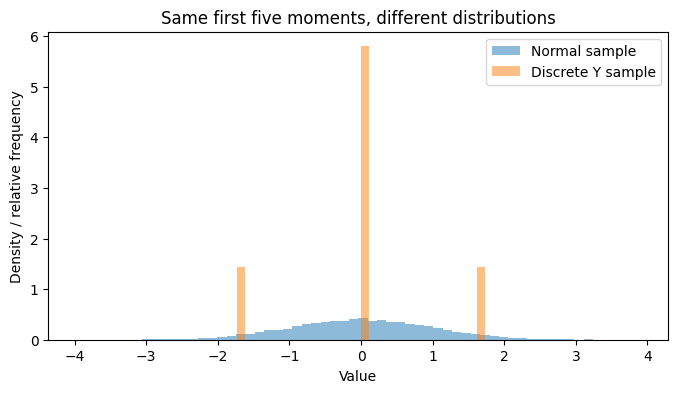

In [21]:
# Solution
n = 20_000
X_sample = rng.normal(0, 1, size=n)
Y_sample = rng.choice(values, size=n, p=probs)

plt.figure(figsize=(8, 4))
plt.hist(X_sample, bins=60, density=True, alpha=0.5, label='Normal sample')
plt.hist(Y_sample, bins=30, density=True, alpha=0.5, label='Discrete Y sample')
plt.xlabel('Value')
plt.ylabel('Density / relative frequency')
plt.title('Same first five moments, different distributions')
plt.legend()
plt.show()

### Solution

The normal random variable takes values continuously over the real line. The variable $Y$ only takes three values: $-\sqrt 3$, $0$, and $\sqrt 3$.

Therefore they cannot have the same distribution, even though their first five moments agree.

## 11. Mean as the Best Constant Predictor Under Squared Loss

A fundamental property of expectation is that the mean minimizes mean squared error:

$$
\operatorname*{arg\,min}_a E[(X-a)^2]=E[X].
$$

### Example 11.1: Numerical check for $X\sim \mathrm{Exponential}(1)$

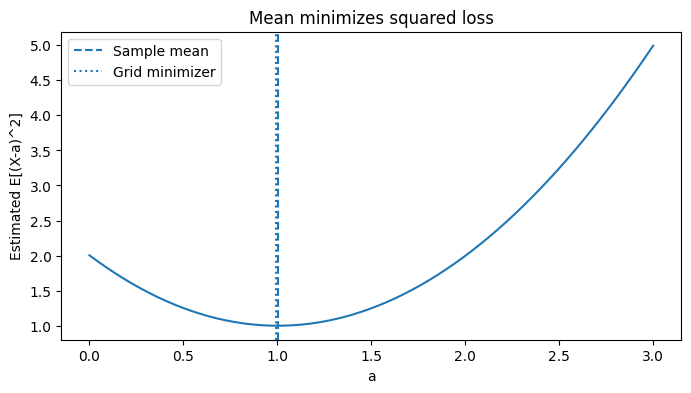

(np.float64(1.001884573143055), np.float64(0.9949748743718593))

In [22]:
n = 300_000
X = rng.exponential(scale=1, size=n)
a_grid = np.linspace(0, 3, 200)
losses = np.array([np.mean((X-a)**2) for a in a_grid])
a_min = a_grid[np.argmin(losses)]

plt.figure(figsize=(8, 4))
plt.plot(a_grid, losses)
plt.axvline(np.mean(X), linestyle='--', label='Sample mean')
plt.axvline(a_min, linestyle=':', label='Grid minimizer')
plt.xlabel('a')
plt.ylabel('Estimated E[(X-a)^2]')
plt.title('Mean minimizes squared loss')
plt.legend()
plt.show()

np.mean(X), a_min

### Solution

For $X\sim \mathrm{Exponential}(1)$, the mean is $1$. The simulated squared loss curve is minimized near $a=1$.

Algebraically,

$$
E[(X-a)^2]=E[X^2]-2aE[X]+a^2.
$$

Differentiating with respect to $a$ gives

$$
\frac{d}{da}E[(X-a)^2]=2a-2E[X].
$$

Setting this equal to zero gives

$$
a=E[X].
$$

### Practice 11.1

For $X\sim \mathrm{Uniform}(0,1)$, numerically verify that the minimizer of $E[(X-a)^2]$ is $a=1/2$.

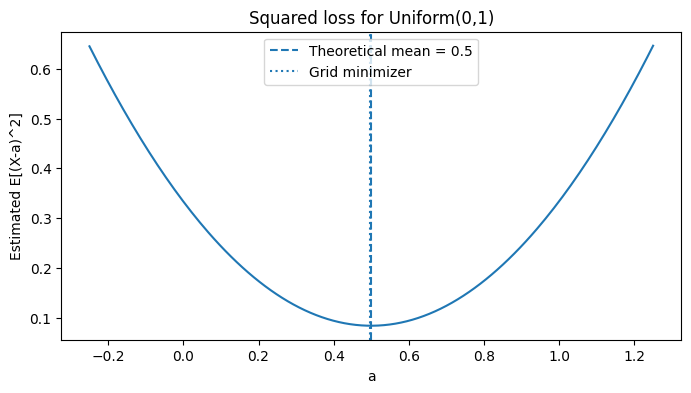

Grid minimizer: 0.49623115577889443
Sample mean: 0.4996116908406477


In [23]:
# Solution
n = 300_000
X = rng.uniform(0, 1, size=n)
a_grid = np.linspace(-0.25, 1.25, 200)
losses = np.array([np.mean((X-a)**2) for a in a_grid])
a_min = a_grid[np.argmin(losses)]

plt.figure(figsize=(8, 4))
plt.plot(a_grid, losses)
plt.axvline(0.5, linestyle='--', label='Theoretical mean = 0.5')
plt.axvline(a_min, linestyle=':', label='Grid minimizer')
plt.xlabel('a')
plt.ylabel('Estimated E[(X-a)^2]')
plt.title('Squared loss for Uniform(0,1)')
plt.legend()
plt.show()

print('Grid minimizer:', a_min)
print('Sample mean:', np.mean(X))

### Solution

For $X\sim \mathrm{Uniform}(0,1)$,

$$
E[X]=\frac12.
$$

The numerical minimizer is close to $0.5$, confirming that the mean minimizes squared loss.

## 12. Summary Table by Simulation

In this section, we compute the mean and variance of several distributions and compare simulation with theory.

In [24]:
n = 500_000
simulations = {
    'Bernoulli(0.3)': rng.binomial(1, 0.3, size=n),
    'Binomial(10,0.3)': rng.binomial(10, 0.3, size=n),
    'Poisson(4)': rng.poisson(4, size=n),
    'Exponential(rate=2)': rng.exponential(scale=1/2, size=n),
    'Gamma(shape=3, rate=2)': rng.gamma(shape=3, scale=1/2, size=n),
    'Uniform(2,5)': rng.uniform(2, 5, size=n),
    'Normal(1, 2^2)': rng.normal(1, 2, size=n),
    'Beta(2,5)': rng.beta(2, 5, size=n)
}

theory = {
    'Bernoulli(0.3)': (0.3, 0.3*0.7),
    'Binomial(10,0.3)': (10*0.3, 10*0.3*0.7),
    'Poisson(4)': (4, 4),
    'Exponential(rate=2)': (1/2, 1/4),
    'Gamma(shape=3, rate=2)': (3/2, 3/4),
    'Uniform(2,5)': ((2+5)/2, (5-2)**2/12),
    'Normal(1, 2^2)': (1, 4),
    'Beta(2,5)': (2/(2+5), (2*5)/((2+5)**2*(2+5+1)))
}

rows = []
for name, x in simulations.items():
    rows.append([
        name,
        np.mean(x), theory[name][0],
        np.var(x, ddof=0), theory[name][1]
    ])

pd.DataFrame(rows, columns=['Distribution', 'Sim Mean', 'Theory Mean', 'Sim Var', 'Theory Var'])

,Distribution,Sim Mean,Theory Mean,Sim Var,Theory Var
0,Bernoulli(0.3),0.300538,0.300000,0.210215,0.21000
1,"Binomial(10,0.3)",3.001004,3.000000,2.098383,2.10000
2,Poisson(4),4.000942,4.000000,3.989101,4.00000
3,Exponential(rate=2),0.500277,0.500000,0.251258,0.25000
4,"Gamma(shape=3, rate=2)",1.501002,1.500000,0.750873,0.75000
5,"Uniform(2,5)",3.499592,3.500000,0.751625,0.75000
6,"Normal(1, 2^2)",1.000200,1.000000,4.000075,4.00000
7,"Beta(2,5)",0.285542,0.285714,0.025487,0.02551


## 13. Additional Practice Problems with Full Solutions

These problems are designed to reinforce Section 4 concepts.

### Problem 13.1: MGF of a Uniform Distribution

Let $X\sim \mathrm{Uniform}(0,c)$. Derive and verify by numerical integration that

$$
M_X(t)=\frac{e^{ct}-1}{ct}, \qquad t\ne 0.
$$

Then use it to find $E[X]$ and $\mathrm{Var}(X)$.

In [25]:
# Solution
c = sp.symbols('c', positive=True)
M_unif = (sp.exp(c*t) - 1)/(c*t)

# Use a Taylor series around t=0 because the formula has removable singularity at t=0.
series = sp.series(M_unif, t, 0, 4)
E1 = sp.limit(sp.diff(M_unif, t, 1), t, 0)
E2 = sp.limit(sp.diff(M_unif, t, 2), t, 0)
Var = sp.simplify(E2 - E1**2)
series, E1, E2, Var

(1 + c*t/2 + c**2*t**2/6 + c**3*t**3/24 + O(t**4), c/2, c**2/3, c**2/12)

### Solution

For $X\sim \mathrm{Uniform}(0,c)$,

$$
M_X(t)=E[e^{tX}]=\int_0^c e^{tx}\frac{1}{c}\,dx
=\frac{e^{ct}-1}{ct}, \qquad t\ne 0.
$$

Using derivatives at $t=0$,

$$
E[X]=\frac{c}{2},
$$

and

$$
E[X^2]=\frac{c^2}{3}.
$$

Therefore

$$
\mathrm{Var}(X)=\frac{c^2}{3}-\left(\frac{c}{2}\right)^2=\frac{c^2}{12}.
$$

### Problem 13.2: Moment of a Lognormal Distribution

Suppose $Y\sim N(0,1)$ and $X=e^Y$. Compute $E[X^k]$ for real $k$ and verify by simulation for $k=1,2,3$.

In [26]:
# Solution
n = 1_000_000
Y = rng.normal(0, 1, size=n)
X = np.exp(Y)
rows = []
for k in [1, 2, 3]:
    sim = np.mean(X**k)
    theory = np.exp(k**2 / 2)
    rows.append([k, sim, theory])

pd.DataFrame(rows, columns=['k', 'Simulated E[X^k]', 'Theoretical exp(k^2/2)'])

,k,Simulated E[X^k],Theoretical exp(k^2/2)
0,1,1.644863,1.648721
1,2,7.330546,7.389056
2,3,89.763505,90.017131


### Solution

Since $X=e^Y$,

$$
E[X^k]=E[e^{kY}].
$$

The MGF of $Y\sim N(0,1)$ is

$$
M_Y(t)=e^{t^2/2}.
$$

Therefore

$$
E[X^k]=E[e^{kY}]=M_Y(k)=e^{k^2/2}.
$$

### Problem 13.3: Sum of Independent Poisson Random Variables

Let $X\sim \mathrm{Poisson}(\lambda_1)$ and $Y\sim \mathrm{Poisson}(\lambda_2)$ be independent. Use MGFs to show

$$
X+Y\sim \mathrm{Poisson}(\lambda_1+\lambda_2).
$$

Verify by simulation with $\lambda_1=2$ and $\lambda_2=5$.

Simulated mean: 6.996776666666666 Theoretical: 7
Simulated variance: 7.011232943455555 Theoretical: 7


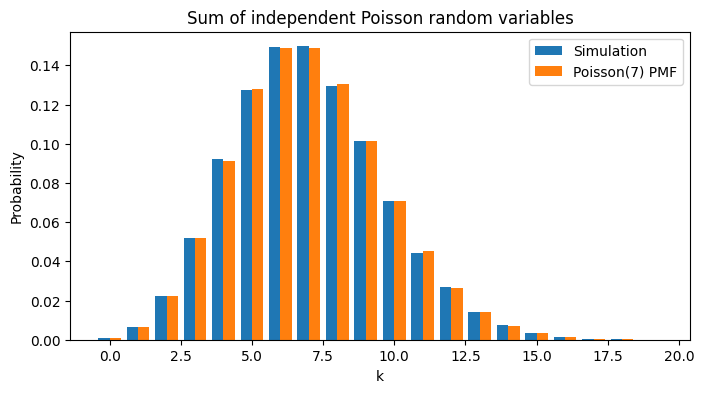

In [27]:
# Solution using simulation
n = 300_000
lam1, lam2 = 2, 5
X = rng.poisson(lam1, size=n)
Y = rng.poisson(lam2, size=n)
Z = X + Y

print('Simulated mean:', np.mean(Z), 'Theoretical:', lam1 + lam2)
print('Simulated variance:', np.var(Z), 'Theoretical:', lam1 + lam2)

k_values = np.arange(0, 20)
empirical = np.array([np.mean(Z == k) for k in k_values])
theoretical = stats.poisson.pmf(k_values, lam1 + lam2)

plt.figure(figsize=(8, 4))
plt.bar(k_values - 0.2, empirical, width=0.4, label='Simulation')
plt.bar(k_values + 0.2, theoretical, width=0.4, label='Poisson(7) PMF')
plt.xlabel('k')
plt.ylabel('Probability')
plt.title('Sum of independent Poisson random variables')
plt.legend()
plt.show()

### Solution

The MGF of $X$ is

$$
M_X(t)=\exp\{\lambda_1(e^t-1)\},
$$

and the MGF of $Y$ is

$$
M_Y(t)=\exp\{\lambda_2(e^t-1)\}.
$$

Since $X$ and $Y$ are independent,

$$
M_{X+Y}(t)=M_X(t)M_Y(t)
=\exp\{(\lambda_1+\lambda_2)(e^t-1)\}.
$$

This is the MGF of a Poisson$(\lambda_1+\lambda_2)$ random variable.

### Problem 13.4: Independence and Expectation of Products

Let $X$ and $Y$ be independent with $X\sim \mathrm{Uniform}(0,1)$ and $Y\sim \mathrm{Exponential}(2)$, where $2$ is the rate. Compute

$$
E[X^2 e^{-Y}]
$$

using independence, and verify by simulation.

In [28]:
# Solution
n = 1_000_000
X = rng.uniform(0, 1, size=n)
Y = rng.exponential(scale=1/2, size=n)
sim = np.mean(X**2 * np.exp(-Y))

# E[X^2]=1/3.
# For Y~Exp(rate=2), E[e^{-Y}] = M_Y(-1) = 2/(2+1)=2/3.
theory = (1/3) * (2/3)
print('Simulation:', sim)
print('Theory:', theory)

Simulation: 0.22214962538714483
Theory: 0.2222222222222222


### Solution

Because $X$ and $Y$ are independent,

$$
E[X^2e^{-Y}]=E[X^2]E[e^{-Y}].
$$

For $X\sim \mathrm{Uniform}(0,1)$,

$$
E[X^2]=\frac13.
$$

For $Y\sim \mathrm{Exponential}(2)$,

$$
E[e^{-Y}] = M_Y(-1)=\frac{2}{2+1}=\frac23.
$$

Thus

$$
E[X^2e^{-Y}]=\frac13\cdot \frac23=\frac29.
$$

### Problem 13.5: Finding Variance from the MGF

Suppose a random variable has MGF

$$
M_X(t)=\left(0.4+0.6e^t\right)^{10}.
$$

Identify the distribution and compute $E[X]$ and $\mathrm{Var}(X)$.

In [29]:
# Solution
p = 0.6
n = 10
mean = n*p
var = n*p*(1-p)
mean, var

(6.0, 2.4000000000000004)

### Solution

The MGF has the form

$$
M_X(t)=((1-p)+pe^t)^n.
$$

Here $n=10$ and $p=0.6$, so

$$
X\sim \mathrm{Binomial}(10,0.6).
$$

Therefore

$$
E[X]=np=10(0.6)=6,
$$

and

$$
\mathrm{Var}(X)=np(1-p)=10(0.6)(0.4)=2.4.
$$

## 14. Lab Checklist

After completing this lab, you should be able to:

- Compute expected values from PMFs and PDFs.
- Interpret expectation as a long-run average.
- Compute $E[g(X)]$ and understand why $E[g(X)]\ne g(E[X])$ in general.
- Use linearity of expectation, including for dependent random variables.
- Compute variance using both definitions.
- Estimate skewness and kurtosis by simulation.
- Use MGFs to recover moments.
- Use MGF rules for affine transformations and sums of independent variables.
- Understand why finitely many moments may not determine a distribution.